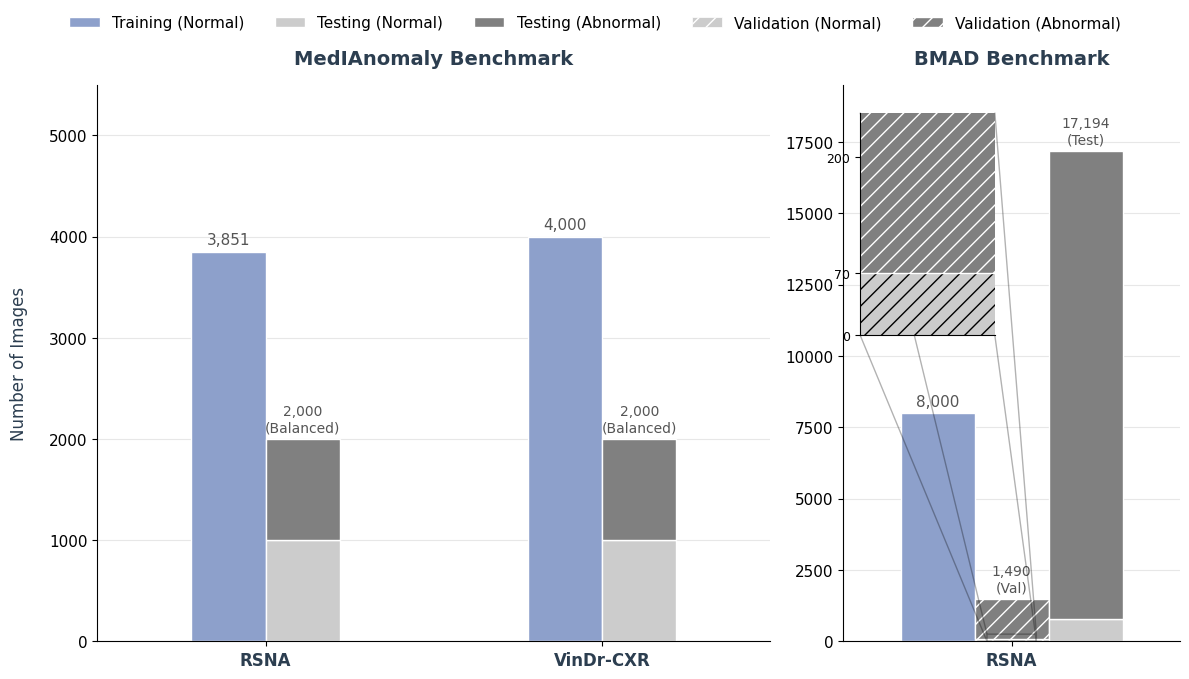

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CẤU HÌNH THẨM MỸ TỐI GIẢN
# ==========================================
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlelocation': 'center',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 11,
    'legend.frameon': False,
    'legend.fontsize': 11
})

# ==========================================
# 2. KHỞI TẠO DỮ LIỆU
# ==========================================
labels_medi = ['RSNA', 'VinDr-CXR']
medi_train = np.array([3851, 4000])     
medi_test_norm = np.array([1000, 1000])  
medi_test_abnorm = np.array([1000, 1000])

labels_bmad = ['RSNA']
bmad_train = np.array([8000])
bmad_val_norm = np.array([70])
bmad_val_abnorm = np.array([1420])
bmad_test_norm = np.array([781])
bmad_test_abnorm = np.array([16413])

color_train   = '#8DA0CB'
color_norm    = '#CCCCCC'
color_abnorm  = '#808080'

# ==========================================
# 3. VẼ BIỂU ĐỒ
# ==========================================
# Tổng figsize được thu hẹp lại giúp đồ thị bớt bị "giãn"
# width_ratios = [2, 1] để đồ thị bên trái to gấp đôi bên phải (do chứa 2 cụm RSNA & VinDrCXR so với 1 cụm RSNA bên phải)
fig, axs = plt.subplots(1, 2, figsize=(12, 6.5), gridspec_kw={'width_ratios': [2, 1]})

width = 0.22

# ------------------------------------------
# SUBPLOT 1: MedIAnomaly
# ------------------------------------------
ax = axs[0]
x_medi = np.arange(len(labels_medi))

ax.bar(x_medi - width/2, medi_train, width, label='Training (Normal)', color=color_train, edgecolor='white')
ax.bar(x_medi + width/2, medi_test_norm, width, label='Testing (Normal)', color=color_norm, edgecolor='white')
ax.bar(x_medi + width/2, medi_test_abnorm, width, bottom=medi_test_norm, label='Testing (Abnormal)', color=color_abnorm, edgecolor='white')

for i in range(len(labels_medi)):
    ax.annotate(f'{medi_train[i]:,}', xy=(x_medi[i] - width/2, medi_train[i]),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=11, color='#555555')
    total_test = medi_test_norm[i] + medi_test_abnorm[i]
    ax.annotate(f'{total_test:,}\n(Balanced)', xy=(x_medi[i] + width/2, total_test),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, color='#555555')

ax.set_title("MedIAnomaly Benchmark", pad=15, color='#2c3e50')
ax.set_ylabel("Number of Images", labelpad=15, color='#2c3e50')
ax.set_xticks(x_medi)
ax.set_xticklabels(labels_medi, fontweight='bold', color='#2c3e50')
ax.set_ylim(0, 5500)
# Khoảng X là 2.0 (-0.5 -> 1.5) tỉ lệ thuận với width_ratio = 2
ax.set_xlim(-0.5, 1.5)

# ------------------------------------------
# SUBPLOT 2: BMAD
# ------------------------------------------
ax = axs[1]
x_bmad = np.arange(len(labels_bmad))

ax.bar(x_bmad - width, bmad_train, width, color=color_train, edgecolor='white')
ax.bar(x_bmad, bmad_val_norm, width, label='Validation (Normal)', color=color_norm, edgecolor='white', hatch='//', linewidth=0.5)
ax.bar(x_bmad, bmad_val_abnorm, width, bottom=bmad_val_norm, label='Validation (Abnormal)', color=color_abnorm, edgecolor='white', hatch='//')
ax.bar(x_bmad + width, bmad_test_norm, width, color=color_norm, edgecolor='white')
ax.bar(x_bmad + width, bmad_test_abnorm, width, bottom=bmad_test_norm, color=color_abnorm, edgecolor='white')

# Annotations BMAD
ax.annotate(f'{bmad_train[0]:,}', xy=(x_bmad[0] - width, bmad_train[0]),
            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=11, color='#555555')

total_val = bmad_val_norm[0] + bmad_val_abnorm[0]
ax.annotate(f'{total_val:,}\n(Val)', xy=(x_bmad[0], total_val),
            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, color='#555555')

total_test_bmad = bmad_test_norm[0] + bmad_test_abnorm[0]
ax.annotate(f'{total_test_bmad:,}\n(Test)', xy=(x_bmad[0] + width, total_test_bmad),
            xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, color='#555555')

ax.set_title("BMAD Benchmark", pad=15, color='#2c3e50')
ax.set_xticks(x_bmad)
ax.set_xticklabels(labels_bmad, fontweight='bold', color='#2c3e50')
ax.set_ylim(0, 19500)
# Khoảng X là 1.0 (-0.5 -> 0.5) tỉ lệ thuận với width_ratio = 1. Nhờ đó, bề ngang các cụm sẽ tương đương với biểu đồ 1.
ax.set_xlim(-0.5, 0.5)

# --- THÊM INSET AXES ĐỂ PHÓNG TO VALIDATION ---
# Chuyển toạ độ Inset lên khu vực trống ở góc TRÊN BÊN TRÁI 
# Trục y bắt đầu từ 0.55 (phần trống ngay phía trên cột Train vốn chỉ cao ~ 40%)
ax_inset = ax.inset_axes([0.05, 0.55, 0.40, 0.40])  # [x, y, width, height]

ax_inset.bar(x_bmad, bmad_val_norm, width, color=color_norm, edgecolor='black', linewidth=0.5, hatch='//')
ax_inset.bar(x_bmad, bmad_val_abnorm, width, bottom=bmad_val_norm, color=color_abnorm, edgecolor='white', hatch='//')

# Focus vào phần gốc của cột
ax_inset.set_xlim(x_bmad[0] - width/3, x_bmad[0] + width/3)
ax_inset.set_ylim(0, 250)
ax_inset.set_xticks([])
ax_inset.set_yticks([0, 70, 200])
ax_inset.tick_params(axis='y', labelsize=9)

# Vẽ đường chéo chỉ báo khu vực Zoom
ax.indicate_inset_zoom(ax_inset, edgecolor="black", alpha=0.3)

# ==========================================
# 4. TINH CHỈNH THẨM MỸ CHUNG
# ==========================================
for axis in axs:
    axis.yaxis.grid(True, linestyle='-', alpha=0.3, color='#B0B0B0')
    axis.set_axisbelow(True)

handles, labels = axs[0].get_legend_handles_labels()
handles2, labels2 = axs[1].get_legend_handles_labels()
fig.legend(handles + handles2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=5)

plt.tight_layout()
plt.show()